# A character-level GPT, written from scratch in NumPy

**Foundations of Machine Learning — final project, Track 3.**

Decoder-only Transformer in NumPy (no autograd). Next-character prediction on Tiny Shakespeare.


# Part 1 — Components

## Setup and gradient checking

Central finite differences for checking hand-written gradients.


In [55]:
from __future__ import annotations

from typing import Callable
import os
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [56]:
def numeric_gradient(
    scalar_function: Callable[[np.ndarray], float],
    feature_values: np.ndarray,
    h: float = 1e-5,
) -> np.ndarray:
    """Central finite differences: the reference gradient every backward pass is checked against."""
    gradient = np.zeros_like(feature_values, dtype=float)

    for i in range(feature_values.size):
        mask = np.zeros_like(feature_values, dtype=float)
        mask.flat[i] = h
        gradient.flat[i] = (
            scalar_function(feature_values + mask) - scalar_function(feature_values - mask)
        ) / (2 * h)
    return gradient


def relative_gradient_error(
    parameter_owner,
    value_attribute: str,
    gradient_attribute: str,
    loss_function: Callable[[], float],
) -> float:
    """Compare one stored analytic gradient against finite differences of `loss_function`."""
    original_values: np.ndarray = getattr(parameter_owner, value_attribute)

    def loss_with_replaced_values(flat_values: np.ndarray) -> float:
        setattr(parameter_owner, value_attribute, flat_values.reshape(original_values.shape))
        loss = loss_function()
        setattr(parameter_owner, value_attribute, original_values)
        return loss

    numerical: np.ndarray = numeric_gradient(loss_with_replaced_values, original_values.copy())
    analytic: np.ndarray = getattr(parameter_owner, gradient_attribute)
    return float(np.abs(analytic - numerical).max() / np.abs(numerical).max())

## `Layer` and `Sequential`

Base class: `parameters()` / `zero_grad()` from `parameter_names` or `children()`.
`Sequential` runs children forward, then backward in reverse.


In [57]:
class Layer:
    """Base class for everything with a forward and a backward pass.

    A layer either owns parameter arrays -- listed in `parameter_names`, each paired with a
    gradient attribute of the same name prefixed by `d_` -- or is composed of the child layers
    returned by `children()`, or both. `parameters()` and `zero_grad()` are derived from those
    two hooks, so no subclass has to implement them.
    """

    parameter_names: tuple[str, ...] = ()

    def children(self) -> list[Layer]:
        return []

    def parameters(self) -> list[tuple[np.ndarray, np.ndarray]]:
        """(value, gradient) pairs for the optimizer: this layer's own, then its children's."""
        collected: list[tuple[np.ndarray, np.ndarray]] = [
            (getattr(self, name), getattr(self, f"d_{name}")) for name in self.parameter_names
        ]
        for child in self.children():
            collected += child.parameters()
        return collected

    def zero_grad(self) -> None:
        """Drop every gradient buffer in this subtree (called after each optimizer step)."""
        for name in self.parameter_names:
            setattr(self, f"d_{name}", None)
        for child in self.children():
            child.zero_grad()


class Sequential(Layer):
    """A chain of layers: forward runs them in order, backward runs them in reverse."""

    def __init__(self, *layers: Layer) -> None:
        self.layers: list[Layer] = list(layers)

    def __getitem__(self, index: int) -> Layer:
        return self.layers[index]

    def children(self) -> list[Layer]:
        return self.layers

    def forward(self, X: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        for layer in reversed(self.layers):
            d_y = layer.backward(d_y)
        return d_y

## `Linear`

`Y = X @ W + b`. Weights scaled by `1/√n_in`.


In [58]:
class Linear(Layer):
    """Fully-connected layer: Y = X @ W + b."""

    parameter_names = ("W", "b")

    def __init__(self, n_in: int, n_out: int, seed: int = 0) -> None:
        rng = np.random.default_rng(seed)

        self.W: np.ndarray = rng.standard_normal((n_in, n_out)) / np.sqrt(n_in)
        self.b: np.ndarray = np.zeros(n_out)

        self.X: np.ndarray | None = None
        self.d_W: np.ndarray | None = None
        self.d_b: np.ndarray | None = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (batch, n_in) -> Y: (batch, n_out)."""
        self.X = X
        return X @ self.W + self.b

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """d_y: (batch, n_out) upstream gradient dL/dY. Returns d_x: (batch, n_in)."""
        self.d_W = self.X.T @ d_y
        self.d_b = d_y.sum(axis=0)
        return d_y @ self.W.T

## Cross-entropy

Mean negative log probability of the true next character. Softmax and log are fused.


In [59]:
def cross_entropy(
    raw_class_scores: np.ndarray,
    correct_class_indices: np.ndarray,
) -> tuple[float, np.ndarray]:
    """Softmax cross-entropy. Returns (mean loss, dL/dscores)."""
    number_of_examples: int = raw_class_scores.shape[0]
    example_rows: np.ndarray = np.arange(number_of_examples)

    stabilized_scores: np.ndarray = raw_class_scores - raw_class_scores.max(axis=1, keepdims=True)
    exponentiated_scores: np.ndarray = np.exp(stabilized_scores)
    class_probabilities: np.ndarray = exponentiated_scores / exponentiated_scores.sum(axis=1, keepdims=True)

    probability_of_correct_class: np.ndarray = class_probabilities[example_rows, correct_class_indices]
    mean_loss: float = float(-np.log(probability_of_correct_class).mean())

    gradient_wrt_scores: np.ndarray = class_probabilities.copy()
    gradient_wrt_scores[example_rows, correct_class_indices] -= 1
    gradient_wrt_scores /= number_of_examples

    return mean_loss, gradient_wrt_scores

## `Adam`

Per-parameter step `m / √v`. Updates must be in place; gradients re-read every step.


In [60]:
class Adam:
    """Adam optimizer: updates every parameter of `model` in place."""

    def __init__(
        self,
        model: Layer,
        lr: float = 1e-3,
        beta1: float = 0.9,
        beta2: float = 0.999,
        eps: float = 1e-8,
    ) -> None:
        self.model: Layer = model
        self.lr: float = lr
        self.beta1: float = beta1
        self.beta2: float = beta2
        self.eps: float = eps
        self.time_step: int = 0

        self.first_moment_estimates: list[np.ndarray] = [
            np.zeros_like(value) for value, _gradient in model.parameters()
        ]
        self.second_moment_estimates: list[np.ndarray] = [
            np.zeros_like(value) for value, _gradient in model.parameters()
        ]

    def step(self) -> None:
        """Apply one Adam update to every parameter, using the current gradients."""
        self.time_step += 1
        bias_correction_first: float = 1.0 - self.beta1 ** self.time_step
        bias_correction_second: float = 1.0 - self.beta2 ** self.time_step

        for index, (parameter_value, parameter_gradient) in enumerate(self.model.parameters()):
            first_moment: np.ndarray = self.first_moment_estimates[index]
            second_moment: np.ndarray = self.second_moment_estimates[index]

            first_moment *= self.beta1
            first_moment += (1.0 - self.beta1) * parameter_gradient
            second_moment *= self.beta2
            second_moment += (1.0 - self.beta2) * (parameter_gradient ** 2)

            corrected_first_moment: np.ndarray = first_moment / bias_correction_first
            corrected_second_moment: np.ndarray = second_moment / bias_correction_second

            parameter_value -= self.lr * corrected_first_moment / (
                np.sqrt(corrected_second_moment) + self.eps
            )

    def zero_grad(self) -> None:
        self.model.zero_grad()

## `CharTokenizer`

Sorted characters → integer ids. 65 symbols on Tiny Shakespeare.


In [61]:
class CharTokenizer:
    """Character-level tokenizer: text <-> integer token ids."""

    def __init__(self, training_text: str) -> None:
        self.id_to_token: list[str] = sorted(set(training_text))
        self.token_to_id: dict[str, int] = {
            token: token_id for token_id, token in enumerate(self.id_to_token)
        }

    @property
    def vocab_size(self) -> int:
        return len(self.id_to_token)

    def encode(self, text: str) -> list[int]:
        return [self.token_to_id[character] for character in text]

    def decode(self, token_ids: list[int]) -> str:
        return "".join(self.id_to_token[token_id] for token_id in token_ids)

## `Embedding`

Learned row lookup. Used for tokens and for positions. Backward uses `np.add.at`.


In [62]:
class Embedding(Layer):
    """Token ids -> learned vectors, by row lookup into a trainable table."""

    parameter_names = ("table",)

    def __init__(self, vocab_size: int, embedding_dim: int, seed: int = 0,
                 init_scale: float = 0.02) -> None:
        random_generator = np.random.default_rng(seed)
        self.table: np.ndarray = (
            random_generator.standard_normal((vocab_size, embedding_dim)) * init_scale
        )
        self.token_ids: np.ndarray | None = None
        self.d_table: np.ndarray | None = None

    def forward(self, token_ids: np.ndarray) -> np.ndarray:
        """token_ids: (T,) -> embeddings: (T, embedding_dim)."""
        self.token_ids = token_ids
        return self.table[token_ids]

    def backward(self, d_out: np.ndarray) -> None:
        """Scatter-add d_out into d_table; repeated ids accumulate. No input gradient."""
        self.d_table = np.zeros_like(self.table)
        np.add.at(self.d_table, self.token_ids, d_out)

## `CausalSelfAttention`

Q, K, V, scaled scores, causal mask (`−∞` on the future), weighted sum of values.


In [63]:
def softmax_rows(scores: np.ndarray) -> np.ndarray:
    """Row-wise stable softmax; tolerates the -inf entries left by the causal mask."""
    shifted: np.ndarray = scores - scores.max(axis=-1, keepdims=True)
    exponentiated: np.ndarray = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=-1, keepdims=True)


class CausalSelfAttention(Layer):
    """Single-head causal self-attention: X (T, d_model) -> (T, d_head)."""

    def __init__(self, d_model: int, d_head: int, seed: int = 0) -> None:
        self.d_head: int = d_head
        self.query_projection: Linear = Linear(d_model, d_head, seed=seed)
        self.key_projection: Linear = Linear(d_model, d_head, seed=seed + 1)
        self.value_projection: Linear = Linear(d_model, d_head, seed=seed + 2)

        self.Q: np.ndarray | None = None
        self.K: np.ndarray | None = None
        self.V: np.ndarray | None = None
        self.attention_weights: np.ndarray | None = None

    def children(self) -> list[Layer]:
        return [self.query_projection, self.key_projection, self.value_projection]

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (T, d_model) -> output: (T, d_head)."""
        sequence_length: int = X.shape[0]

        self.Q = self.query_projection.forward(X)
        self.K = self.key_projection.forward(X)
        self.V = self.value_projection.forward(X)

        raw_scores: np.ndarray = (self.Q @ self.K.T) / np.sqrt(self.d_head)

        allowed_positions: np.ndarray = np.tril(
            np.ones((sequence_length, sequence_length), dtype=bool)
        )
        masked_scores: np.ndarray = np.where(allowed_positions, raw_scores, -np.inf)

        self.attention_weights = softmax_rows(masked_scores)
        return self.attention_weights @ self.V

    def backward(self, d_out: np.ndarray) -> np.ndarray:
        """d_out: dL/doutput (T, d_head). Returns d_x: dL/dX (T, d_model)."""
        d_attention_weights: np.ndarray = d_out @ self.V.T
        d_v: np.ndarray = self.attention_weights.T @ d_out

        row_weighted_sum: np.ndarray = (
            d_attention_weights * self.attention_weights
        ).sum(axis=-1, keepdims=True)
        d_masked_scores: np.ndarray = self.attention_weights * (
            d_attention_weights - row_weighted_sum
        )
        d_raw_scores: np.ndarray = d_masked_scores / np.sqrt(self.d_head)

        d_q: np.ndarray = d_raw_scores @ self.K
        d_k: np.ndarray = d_raw_scores.T @ self.Q

        return (
            self.query_projection.backward(d_q)
            + self.key_projection.backward(d_k)
            + self.value_projection.backward(d_v)
        )

## `MultiHeadAttention`

`h` heads in parallel, then concatenate and project.


In [64]:
class MultiHeadAttention(Layer):
    """Several causal self-attention heads in parallel, concatenated and projected."""

    def __init__(self, d_model: int, number_of_heads: int, seed: int = 0) -> None:
        if d_model % number_of_heads != 0:
            raise ValueError(
                f"d_model ({d_model}) must be divisible by number_of_heads ({number_of_heads})"
            )
        self.number_of_heads: int = number_of_heads
        self.heads: list[CausalSelfAttention] = [
            CausalSelfAttention(d_model, d_model // number_of_heads, seed=seed + 10 * head_index)
            for head_index in range(number_of_heads)
        ]
        self.output_projection: Linear = Linear(d_model, d_model, seed=seed + 7)

    def children(self) -> list[Layer]:
        return [*self.heads, self.output_projection]

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (T, d_model) -> output: (T, d_model)."""
        head_outputs: list[np.ndarray] = [head.forward(X) for head in self.heads]
        return self.output_projection.forward(np.concatenate(head_outputs, axis=-1))

    def backward(self, d_out: np.ndarray) -> np.ndarray:
        """d_out: dL/doutput (T, d_model). Returns d_x: dL/dX (T, d_model)."""
        d_concatenated: np.ndarray = self.output_projection.backward(d_out)
        per_head_gradients: list[np.ndarray] = np.split(
            d_concatenated, self.number_of_heads, axis=-1
        )

        d_x: np.ndarray = np.zeros_like(d_concatenated)
        for head, head_gradient in zip(self.heads, per_head_gradients):
            d_x += head.backward(head_gradient)
        return d_x

## `LayerNorm`

Per-token mean/variance, then `gamma` and `beta`.


In [65]:
class LayerNorm(Layer):
    """Normalizes each token across its features, then scales by gamma and shifts by beta."""

    parameter_names = ("gamma", "beta")

    def __init__(self, d_model: int, eps: float = 1e-5) -> None:
        self.eps: float = eps
        self.gamma: np.ndarray = np.ones(d_model)
        self.beta: np.ndarray = np.zeros(d_model)

        self.normalized_input: np.ndarray | None = None
        self.standard_deviation: np.ndarray | None = None
        self.d_gamma: np.ndarray | None = None
        self.d_beta: np.ndarray | None = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """X: (..., d_model) -> Y: (..., d_model). Normalizes over the LAST axis."""
        feature_mean: np.ndarray = X.mean(axis=-1, keepdims=True)
        feature_variance: np.ndarray = X.var(axis=-1, keepdims=True)

        self.standard_deviation = np.sqrt(feature_variance + self.eps)
        self.normalized_input = (X - feature_mean) / self.standard_deviation

        return self.gamma * self.normalized_input + self.beta

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """d_y: dL/dY (..., d_model). Returns d_x: dL/dX (..., d_model)."""
        summed_axes: tuple[int, ...] = tuple(range(d_y.ndim - 1))
        self.d_gamma = (d_y * self.normalized_input).sum(axis=summed_axes)
        self.d_beta = d_y.sum(axis=summed_axes)

        d_normalized: np.ndarray = d_y * self.gamma
        mean_of_d_normalized: np.ndarray = d_normalized.mean(axis=-1, keepdims=True)
        mean_of_d_normalized_times_x_hat: np.ndarray = (
            d_normalized * self.normalized_input
        ).mean(axis=-1, keepdims=True)

        return (
            d_normalized
            - mean_of_d_normalized
            - self.normalized_input * mean_of_d_normalized_times_x_hat
        ) / self.standard_deviation

## `Gelu` and `FeedForward`

`Linear → GELU → Linear` with a ×4 hidden width. `FeedForward` is a `Sequential`.


In [66]:
class Gelu(Layer):
    """GELU activation (tanh approximation), elementwise. No parameters."""

    INNER_COEFFICIENT: float = 0.044715

    def __init__(self) -> None:
        self.X: np.ndarray | None = None

    def _inner(self, X: np.ndarray) -> np.ndarray:
        """The argument of tanh: sqrt(2/pi) * (x + 0.044715 x^3)."""
        return np.sqrt(2.0 / np.pi) * (X + self.INNER_COEFFICIENT * X ** 3)

    def forward(self, X: np.ndarray) -> np.ndarray:
        self.X = X
        return 0.5 * X * (1.0 + np.tanh(self._inner(X)))

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """Elementwise chain rule: d_x = d_y * gelu'(x)."""
        X: np.ndarray = self.X
        tanh_of_inner: np.ndarray = np.tanh(self._inner(X))
        d_inner_d_x: np.ndarray = np.sqrt(2.0 / np.pi) * (
            1.0 + 3.0 * self.INNER_COEFFICIENT * X ** 2
        )
        gelu_derivative: np.ndarray = 0.5 * (1.0 + tanh_of_inner) + 0.5 * X * (
            1.0 - tanh_of_inner ** 2
        ) * d_inner_d_x
        return d_y * gelu_derivative


class FeedForward(Sequential):
    """Position-wise MLP: Linear(d -> 4d) -> GELU -> Linear(4d -> d)."""

    def __init__(self, d_model: int, expansion_factor: int = 4, seed: int = 0) -> None:
        hidden_dim: int = expansion_factor * d_model
        super().__init__(
            Linear(d_model, hidden_dim, seed=seed),
            Gelu(),
            Linear(hidden_dim, d_model, seed=seed + 1),
        )

## `TransformerBlock`

Pre-norm residual: attention, then MLP. `Y = X + branch(norm(X))`.


In [67]:
class ResidualSublayer(Layer):
    """Pre-norm residual wrapper: Y = X + branch(norm(X))."""

    def __init__(self, norm: LayerNorm, branch: Layer) -> None:
        self.norm: LayerNorm = norm
        self.branch: Layer = branch

    def children(self) -> list[Layer]:
        return [self.norm, self.branch]

    def forward(self, X: np.ndarray) -> np.ndarray:
        return X + self.branch.forward(self.norm.forward(X))

    def backward(self, d_y: np.ndarray) -> np.ndarray:
        """The skip path contributes d_y unchanged; the branch contributes the rest."""
        return d_y + self.norm.backward(self.branch.backward(d_y))


class TransformerBlock(Sequential):
    """Pre-norm decoder block: an attention sub-layer, then a feed-forward sub-layer."""

    def __init__(self, d_model: int, number_of_heads: int, expansion_factor: int = 4,
                 seed: int = 0) -> None:
        super().__init__(
            ResidualSublayer(
                LayerNorm(d_model),
                MultiHeadAttention(d_model, number_of_heads, seed=seed),
            ),
            ResidualSublayer(
                LayerNorm(d_model),
                FeedForward(d_model, expansion_factor, seed=seed + 100),
            ),
        )

    @property
    def attention(self) -> MultiHeadAttention:
        """The attention sub-layer, for inspecting a trained block."""
        return self.layers[0].branch

## `CharGPT`

Token + position embeddings, `N` blocks, LayerNorm, linear head. `generate()` samples the last position.


In [68]:
class CharGPT(Layer):
    """Decoder-only Transformer over one sequence of character ids."""

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 64,
        number_of_heads: int = 4,
        number_of_blocks: int = 3,
        max_sequence_length: int = 64,
        expansion_factor: int = 4,
        seed: int = 0,
    ) -> None:
        self.vocab_size: int = vocab_size
        self.max_sequence_length: int = max_sequence_length

        self.token_embedding: Embedding = Embedding(vocab_size, d_model, seed=seed)
        self.position_embedding: Embedding = Embedding(max_sequence_length, d_model, seed=seed + 1)
        self.blocks: Sequential = Sequential(*[
            TransformerBlock(d_model, number_of_heads, expansion_factor,
                             seed=seed + 20 * (block_index + 1))
            for block_index in range(number_of_blocks)
        ])
        self.output_head: Sequential = Sequential(
            LayerNorm(d_model),
            Linear(d_model, vocab_size, seed=seed + 5),
        )

    def children(self) -> list[Layer]:
        return [self.token_embedding, self.position_embedding, self.blocks, self.output_head]

    def forward(self, token_ids: np.ndarray) -> np.ndarray:
        """token_ids: (T,) integer ids -> logits: (T, vocab_size)."""
        sequence_length: int = len(token_ids)
        if sequence_length > self.max_sequence_length:
            raise ValueError(
                f"sequence length {sequence_length} exceeds max_sequence_length "
                f"{self.max_sequence_length}"
            )

        hidden_states: np.ndarray = (
            self.token_embedding.forward(token_ids)
            + self.position_embedding.forward(np.arange(sequence_length))
        )
        return self.output_head.forward(self.blocks.forward(hidden_states))

    def backward(self, gradient_wrt_logits: np.ndarray) -> None:
        """Backprop from the loss gradient down to both embedding tables."""
        d_hidden: np.ndarray = self.blocks.backward(
            self.output_head.backward(gradient_wrt_logits)
        )
        self.token_embedding.backward(d_hidden)
        self.position_embedding.backward(d_hidden)

    def parameter_count(self) -> int:
        return int(sum(value.size for value, _gradient in self.parameters()))

    def generate(
        self,
        tokenizer: CharTokenizer,
        max_new_tokens: int = 200,
        temperature: float = 1.0,
        seed: int = 0,
        prompt: str = "\n",
    ) -> str:
        """Autoregressive sampling. Crops the context to max_sequence_length each step."""
        random_generator = np.random.default_rng(seed)
        generated_ids: list[int] = tokenizer.encode(prompt)

        for _ in range(max_new_tokens):
            context_ids: np.ndarray = np.array(generated_ids[-self.max_sequence_length:])
            logits: np.ndarray = self.forward(context_ids)
            probabilities: np.ndarray = softmax_rows(logits[-1] / temperature)
            generated_ids.append(int(random_generator.choice(self.vocab_size, p=probabilities)))

        return tokenizer.decode(generated_ids)

## Gradient checks

End-to-end embedding gradient, one attention weight, and a causal-mask check.


In [69]:
check_model = CharGPT(vocab_size=20, d_model=16, number_of_heads=2, number_of_blocks=2,
                      max_sequence_length=8)
input_ids = np.array([3, 7, 1, 4, 3])
target_ids = np.array([7, 1, 4, 3, 9])


def check_model_loss() -> float:
    return cross_entropy(check_model.forward(input_ids), target_ids)[0]


_loss, gradient_wrt_logits = cross_entropy(check_model.forward(input_ids), target_ids)
check_model.backward(gradient_wrt_logits)

query_projection = check_model.blocks[0].attention.heads[0].query_projection
print("end-to-end check, character embedding table : relative error "
      f"{relative_gradient_error(check_model.token_embedding, 'table', 'd_table', check_model_loss):.2e}")
print("end-to-end check, attention query weights   : relative error "
      f"{relative_gradient_error(query_projection, 'W', 'd_W', check_model_loss):.2e}")

random_generator = np.random.default_rng(0)
attention = CausalSelfAttention(d_model=8, d_head=4)
sequence = random_generator.standard_normal((5, 8))
output_before = attention.forward(sequence).copy()
sequence_with_changed_future = sequence.copy()
sequence_with_changed_future[-1] += 10.0
output_after = attention.forward(sequence_with_changed_future)
print("causal mask, earlier outputs changed by     : "
      f"{np.abs(output_before[:-1] - output_after[:-1]).max():.2e}")

print(f"\nlogits shape {check_model.forward(input_ids).shape}, "
      f"{check_model.parameter_count():,} parameters")

end-to-end check, character embedding table : relative error 1.18e-07
end-to-end check, attention query weights   : relative error 5.95e-10
causal mask, earlier outputs changed by     : 0.00e+00

logits shape (5, 20), 7,380 parameters


# Part 2 — Training

## Dataset

Tiny Shakespeare (~1.1M chars). Last 10% held out as a contiguous tail.


In [70]:
DATA_PATH: str = "data/tinyshakespeare.txt"
DATA_URL: str = ("https://raw.githubusercontent.com/karpathy/char-rnn/"
                 "master/data/tinyshakespeare/input.txt")

if not os.path.exists(DATA_PATH):
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, encoding="utf-8") as corpus_file:
    shakespeare_text: str = corpus_file.read()

shakespeare_tokenizer = CharTokenizer(shakespeare_text)
all_token_ids: np.ndarray = np.array(shakespeare_tokenizer.encode(shakespeare_text))

split_index: int = int(0.9 * len(all_token_ids))
train_token_ids: np.ndarray = all_token_ids[:split_index]
validation_token_ids: np.ndarray = all_token_ids[split_index:]

shakespeare_baseline_loss: float = float(np.log(shakespeare_tokenizer.vocab_size))

print(f"characters      : {len(shakespeare_text):,}")
print(f"vocabulary      : {shakespeare_tokenizer.vocab_size} unique characters")
print(f"train tokens    : {len(train_token_ids):,}")
print(f"validation      : {len(validation_token_ids):,}")
print(f"uniform baseline: {shakespeare_baseline_loss:.3f} nats/char "
      f"(perplexity {np.exp(shakespeare_baseline_loss):.1f})")
print(f"\nfirst 200 characters:\n{shakespeare_text[:200]}")

characters      : 1,115,394
vocabulary      : 65 unique characters
train tokens    : 1,003,854
validation      : 111,540
uniform baseline: 4.174 nats/char (perplexity 65.0)

first 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## Training loop

Random windows, teacher forcing. `d_model=128`, 4 heads, 3 blocks, 16,000 steps.


In [71]:
BLOCK_SIZE: int = 64
TRAINING_STEPS: int = 16000
EVALUATE_EVERY: int = 1000
LEARNING_RATE: float = 5e-4


def build_model(d_model: int = 128, number_of_heads: int = 4,
                number_of_blocks: int = 3) -> CharGPT:
    """The model under study; the hyperparameter sweep varies these three arguments."""
    return CharGPT(
        shakespeare_tokenizer.vocab_size,
        d_model=d_model,
        number_of_heads=number_of_heads,
        number_of_blocks=number_of_blocks,
        max_sequence_length=BLOCK_SIZE,
    )


def sample_window(
    token_ids: np.ndarray,
    block_size: int,
    random_generator: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """One random training pair: block_size characters in, the same window shifted one right out."""
    window_start = int(random_generator.integers(0, len(token_ids) - block_size - 1))
    window = token_ids[window_start:window_start + block_size + 1]
    return window[:-1], window[1:]


def window_loss(
    model: CharGPT,
    token_ids: np.ndarray,
    block_size: int,
    random_generator: np.random.Generator,
) -> tuple[float, np.ndarray]:
    """Loss and dL/dlogits for one random window -- the unit of both training and evaluation."""
    inputs, targets = sample_window(token_ids, block_size, random_generator)
    return cross_entropy(model.forward(inputs), targets)


def estimate_loss(
    model: CharGPT,
    token_ids: np.ndarray,
    block_size: int,
    number_of_windows: int = 20,
    seed: int = 0,
) -> float:
    """Average loss over random windows -- the held-out validation estimate."""
    random_generator = np.random.default_rng(seed)
    return float(np.mean([
        window_loss(model, token_ids, block_size, random_generator)[0]
        for _ in range(number_of_windows)
    ]))

In [72]:
def print_progress(step_index: int, steps: int, train_loss: float, validation_loss: float,
                   started_at: float) -> None:
    """One row of the progress table, with a linear estimate of the time remaining."""
    elapsed_seconds = time.time() - started_at
    remaining_seconds = elapsed_seconds * (steps - step_index) / step_index
    print(f"{step_index:>6}/{steps:<5}  {train_loss:>7.3f}  {validation_loss:>7.3f}  "
          f"{elapsed_seconds:>7.0f}s  {remaining_seconds:>5.0f}s")


def train_with_validation(
    model: CharGPT,
    train_token_ids: np.ndarray,
    validation_token_ids: np.ndarray,
    steps: int,
    block_size: int,
    lr: float,
    evaluate_every: int = 500,
    seed: int = 0,
    verbose: bool = True,
) -> tuple[list[float], list[int], list[float]]:
    """Trains on random windows, evaluating on held-out data every `evaluate_every` steps."""
    random_generator = np.random.default_rng(seed)
    optimizer = Adam(model, lr=lr)
    started_at = time.time()

    train_loss_history: list[float] = []
    evaluated_steps: list[int] = []
    validation_loss_history: list[float] = []

    if verbose:
        print(f"{'step':>12}  {'train':>7}  {'val':>7}  {'elapsed':>8}  {'left':>6}")

    for step_index in range(1, steps + 1):
        loss, gradient_wrt_logits = window_loss(
            model, train_token_ids, block_size, random_generator
        )
        model.backward(gradient_wrt_logits)
        optimizer.step()
        optimizer.zero_grad()
        train_loss_history.append(loss)

        if step_index % evaluate_every == 0 or step_index == steps:
            validation_loss = estimate_loss(model, validation_token_ids, block_size, seed=1)
            evaluated_steps.append(step_index)
            validation_loss_history.append(validation_loss)

            if verbose:
                print_progress(step_index, steps,
                               float(np.mean(train_loss_history[-evaluate_every:])),
                               validation_loss, started_at)

    return train_loss_history, evaluated_steps, validation_loss_history

In [73]:
shakespeare_model = build_model()
print(f"parameters : {shakespeare_model.parameter_count():,}")
print(f"training   : {TRAINING_STEPS:,} steps, context {BLOCK_SIZE}, lr {LEARNING_RATE:g}")
print("(~2 minutes)\n")

train_losses, evaluated_steps, validation_losses = train_with_validation(
    shakespeare_model,
    train_token_ids,
    validation_token_ids,
    steps=TRAINING_STEPS,
    block_size=BLOCK_SIZE,
    lr=LEARNING_RATE,
    evaluate_every=EVALUATE_EVERY,
)

final_validation_loss: float = validation_losses[-1]
print(f"\ntrain loss : {np.mean(train_losses[:50]):.3f} -> {np.mean(train_losses[-200:]):.3f}")
print(f"val   loss : {validation_losses[0]:.3f} -> {final_validation_loss:.3f}")

parameters : 619,969
training   : 16,000 steps, context 64, lr 0.0005
(~2 minutes)

        step    train      val   elapsed    left
  1000/16000    2.714    2.493       18s    264s
  2000/16000    2.483    2.365       35s    246s
  3000/16000    2.312    2.246       52s    227s
  4000/16000    2.171    2.157       70s    209s
  5000/16000    2.075    2.128       87s    191s
  6000/16000    1.993    2.060      104s    174s
  7000/16000    1.928    2.005      122s    156s
  8000/16000    1.876    1.949      139s    139s
  9000/16000    1.838    1.989      157s    122s
 10000/16000    1.815    1.926      174s    105s
 11000/16000    1.780    1.908      192s     87s
 12000/16000    1.754    1.883      209s     70s
 13000/16000    1.736    1.864      227s     52s
 14000/16000    1.721    1.861      244s     35s
 15000/16000    1.696    1.819      262s     17s
 16000/16000    1.694    1.821      280s      0s

train loss : 3.434 -> 1.718
val   loss : 2.493 -> 1.821


### Learning curves

Raw per-step loss, moving average, and validation.


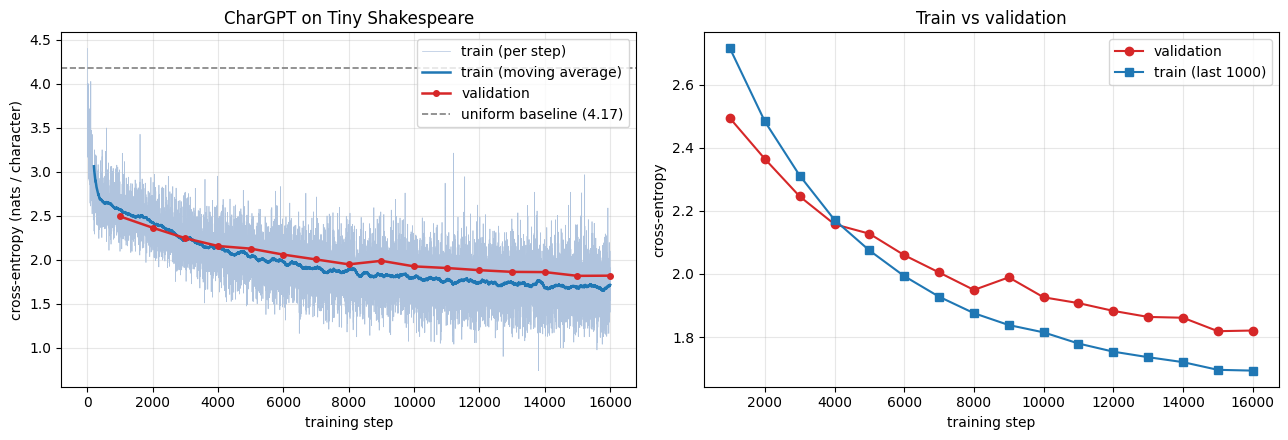

train/val gap at the end: 0.127 nats


In [74]:
def moving_average(values: list[float], window: int = 200) -> np.ndarray:
    """Box-filter smoothing, to make a noisy per-step trace readable."""
    if len(values) < window:
        return np.array(values)
    return np.convolve(np.array(values), np.ones(window) / window, mode="valid")


def train_loss_at(evaluated_steps: list[int], train_losses: list[float], window: int) -> list[float]:
    """Training loss averaged over the `window` steps before each evaluation point."""
    return [float(np.mean(train_losses[step - window:step])) for step in evaluated_steps]


def plot_learning_curves(
    train_losses: list[float],
    evaluated_steps: list[int],
    validation_losses: list[float],
    baseline_loss: float,
    evaluate_every: int,
) -> None:
    """Left: the whole run against the uniform baseline. Right: train vs validation only."""
    figure, (loss_axis, zoom_axis) = plt.subplots(1, 2, figsize=(13, 4.5))

    smoothed = moving_average(train_losses, 200)
    loss_axis.plot(train_losses, color="lightsteelblue", linewidth=0.5, label="train (per step)")
    loss_axis.plot(np.arange(len(smoothed)) + 200, smoothed, color="tab:blue", linewidth=1.8,
                   label="train (moving average)")
    loss_axis.plot(evaluated_steps, validation_losses, "o-", color="tab:red", linewidth=1.8,
                   markersize=4, label="validation")
    loss_axis.axhline(baseline_loss, color="gray", linestyle="--", linewidth=1.2,
                      label=f"uniform baseline ({baseline_loss:.2f})")
    loss_axis.set_xlabel("training step")
    loss_axis.set_ylabel("cross-entropy (nats / character)")
    loss_axis.set_title("CharGPT on Tiny Shakespeare")
    loss_axis.legend()
    loss_axis.grid(alpha=0.3)

    zoom_axis.plot(evaluated_steps, validation_losses, "o-", color="tab:red", label="validation")
    zoom_axis.plot(evaluated_steps, train_loss_at(evaluated_steps, train_losses, evaluate_every),
                   "s-", color="tab:blue", label=f"train (last {evaluate_every})")
    zoom_axis.set_xlabel("training step")
    zoom_axis.set_ylabel("cross-entropy")
    zoom_axis.set_title("Train vs validation")
    zoom_axis.legend()
    zoom_axis.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_learning_curves(train_losses, evaluated_steps, validation_losses,
                     shakespeare_baseline_loss, EVALUATE_EVERY)

final_train_loss = train_loss_at(evaluated_steps, train_losses, EVALUATE_EVERY)[-1]
print(f"train/val gap at the end: {abs(final_train_loss - final_validation_loss):.3f} nats")

## Evaluation

Perplexity and generated samples at a few temperatures.


In [75]:
def show_sample(heading: str, text: str) -> None:
    print(f"\n{'=' * 70}\n{heading}\n{'=' * 70}\n{text}")


validation_perplexity: float = float(np.exp(final_validation_loss))
baseline_perplexity: float = float(np.exp(shakespeare_baseline_loss))

print(f"validation loss       : {final_validation_loss:.3f} nats/char")
print(f"validation perplexity : {validation_perplexity:.2f}")
print(f"uniform baseline      : {baseline_perplexity:.2f}")
print(f"improvement           : {baseline_perplexity / validation_perplexity:.1f}x better "
      f"than random guessing")

for temperature in [0.5, 0.8, 1.0]:
    show_sample(f"sample at temperature {temperature}", shakespeare_model.generate(
        shakespeare_tokenizer, max_new_tokens=400, temperature=temperature, seed=1
    ))

show_sample("continuing the prompt 'ROMEO:'", shakespeare_model.generate(
    shakespeare_tokenizer, max_new_tokens=300, temperature=0.8, seed=7, prompt="ROMEO:"
))

validation loss       : 1.821 nats/char
validation perplexity : 6.18
uniform baseline      : 65.00
improvement           : 10.5x better than random guessing

sample at temperature 0.5


Well, my lord, but there of will subjection,
And thee but sick the to sunt the some burnare admen thee,
And in or chering me changering up a canner from in the world
Whom the bound holds the kneed cheerein of but the state,
That he would a fare in that he bears and with much the both to the would
And there and in that fraight been much the forge,
And god see the do the in it this come consure the

sample at temperature 0.8

Come, the so, for childst of you.

RICHARD:
What thou.

QUEEN MARGARET:
Whe surping this god Glord, pition eye a stand men:
I beancerfore, math much as holight, you dow you.

KING HENR Lord:
She may dong the shamen sahe cree! I am now.

QUEEN MARGARET:
The bears I betimen that becare to stages, for god mercy
In give a deuble a being to to recome,
This come are to become in butdestree

## Hyperparameter study

Six configs, 2,000 steps each, one factor changed from the baseline.


In [ ]:
def run_configuration(label: str, d_model: int, number_of_heads: int, number_of_blocks: int,
                      lr: float, steps: int = 2000) -> dict:
    """Train a fresh model on a short budget and report its held-out loss."""
    model = build_model(d_model=d_model, number_of_heads=number_of_heads,
                        number_of_blocks=number_of_blocks)
    _train_losses, _evaluated_steps, validation_history = train_with_validation(
        model, train_token_ids, validation_token_ids,
        steps=steps, block_size=BLOCK_SIZE, lr=lr, evaluate_every=steps, verbose=False,
    )
    return {
        "label": label,
        "d_model": d_model,
        "heads": number_of_heads,
        "blocks": number_of_blocks,
        "lr": lr,
        "parameters": model.parameter_count(),
        "validation_loss": validation_history[-1],
    }


def print_results_table(results: list[dict]) -> None:
    print(f"{'configuration':<24}{'d_model':>8}{'heads':>7}{'blocks':>8}"
          f"{'lr':>9}{'params':>10}{'val loss':>10}")
    print("-" * 76)
    for result in results:
        print(f"{result['label']:<24}{result['d_model']:>8}{result['heads']:>7}"
              f"{result['blocks']:>8}{result['lr']:>9.0e}{result['parameters']:>10,}"
              f"{result['validation_loss']:>10.3f}")


def plot_configuration_comparison(results: list[dict], baseline_loss: float) -> None:
    figure, axis = plt.subplots(figsize=(8, 4))
    axis.barh([row["label"] for row in results], [row["validation_loss"] for row in results],
              color=["tab:green" if index == 0 else "tab:blue" for index in range(len(results))])
    axis.axvline(baseline_loss, color="gray", linestyle="--",
                 label=f"uniform baseline ({baseline_loss:.2f})")
    axis.set_xlabel("validation loss after 2000 steps (lower is better)")
    axis.set_title("Hyperparameter study")
    axis.legend()
    plt.tight_layout()
    plt.show()


configurations = [
    ("baseline",               128, 4, 3, 5e-4),
    ("lr 10x higher",          128, 4, 3, 5e-3),
    ("lr 5x lower",            128, 4, 3, 1e-4),
    ("narrower (d_model 64)",   64, 4, 3, 5e-4),
    ("shallower (1 block)",    128, 4, 1, 5e-4),
    ("single head",            128, 1, 3, 5e-4),
]

results = sorted([run_configuration(*configuration) for configuration in configurations],
                 key=lambda row: row["validation_loss"])

print_results_table(results)
print(f"\nbest after 2000 steps: {results[0]['label']} "
      f"(val loss {results[0]['validation_loss']:.3f})")

plot_configuration_comparison(results, shakespeare_baseline_loss)

## Lessons learned

- Missing `1/√n_in` in `Linear` passed every gradient check but training started at loss 14.8.
- Learning rate mattered more than depth or width on this budget.
- A 2,000-step sweep ranks early speed, not the final model.
- No batching: one window per step. Next would be a batch axis, then BPE.
